**Import all The Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Reading the CSV File**

In [2]:
df=pd.read_csv("medical_insurance.csv")

**Displaying the Output File**

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


**Droping the Region Column** 

because it is not required

In [4]:
df=df.drop('region',axis=1)

**Displaying the Output File**

In [5]:
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
2767,47,female,45.320,1,no,8569.86180
2768,21,female,34.600,0,no,2020.17700
2769,19,male,26.030,1,yes,16450.89470
2770,23,male,18.715,0,no,21595.38229


**Displaying the Total Null Values**

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

**Counting the Values in Smoker Column**

In [7]:
df['smoker'].value_counts()

smoker
no     2208
yes     564
Name: count, dtype: int64

**Counting the Values in Sex Column**

In [8]:
df['sex'].value_counts()

sex
male      1406
female    1366
Name: count, dtype: int64

**Changing the Values of Sex Column to Integer**

In [9]:
df['sex']=df['sex'].map({'female':0,'male':1})

In [10]:
df

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,yes,16884.92400
1,18,1,33.770,1,no,1725.55230
2,28,1,33.000,3,no,4449.46200
3,33,1,22.705,0,no,21984.47061
4,32,1,28.880,0,no,3866.85520
...,...,...,...,...,...,...
2767,47,0,45.320,1,no,8569.86180
2768,21,0,34.600,0,no,2020.17700
2769,19,1,26.030,1,yes,16450.89470
2770,23,1,18.715,0,no,21595.38229


**Changing the Values in Smoker Column to Integer**

In [11]:
df['smoker']=df['smoker'].map({'yes':1,'no':0})

In [12]:
df

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520
...,...,...,...,...,...,...
2767,47,0,45.320,1,0,8569.86180
2768,21,0,34.600,0,0,2020.17700
2769,19,1,26.030,1,1,16450.89470
2770,23,1,18.715,0,0,21595.38229


**Analysing the Values in Sex and Children Columns Using Graph**

<Axes: xlabel='sex'>

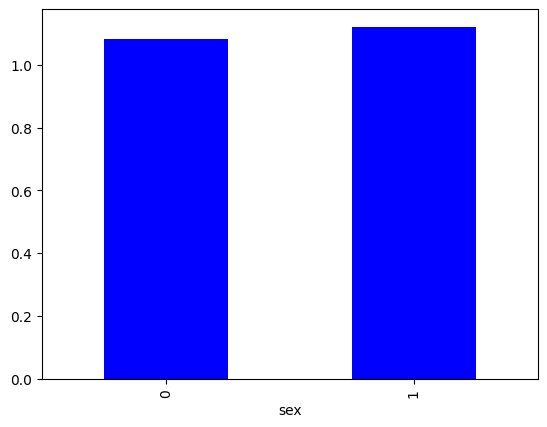

In [13]:
df.groupby("sex")["children"].mean().plot(kind='bar',color='blue')

**Displaying the Correlation**

In [14]:
df.corr()

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,0.298624
sex,-0.026046,1.000000,0.042924,0.016020,0.082326,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,0.199846
children,0.037574,0.016020,-0.001492,1.000000,0.006362,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.788783
charges,0.298624,0.062837,0.199846,0.066442,0.788783,1.000000


**Model Building Using SkLearn And Importing LinearRegression**

In [15]:
from sklearn.linear_model import LinearRegression

**Asigning The LinearRegression to Model**

In [16]:
model=LinearRegression()

**Importing train_test_split to train and test the data for prediction**

In [17]:
from sklearn.model_selection import train_test_split

**Input DataFrame**

In [18]:
x=df.drop('charges',axis=1)

In [19]:
x

,age,sex,bmi,children,smoker
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0
...,...,...,...,...,...
2767,47,0,45.320,1,0
2768,21,0,34.600,0,0
2769,19,1,26.030,1,1
2770,23,1,18.715,0,0


**Output DataFrame**

In [20]:
y=df['charges']

In [21]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
2767     8569.86180
2768     2020.17700
2769    16450.89470
2770    21595.38229
2771     9850.43200
Name: charges, Length: 2772, dtype: float64

**Spliting the Data into Testing and Training Part**

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=80)

**Model Training**

In [23]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Predicting Values Using Trained Model**

In [24]:
y_pred=model.predict(x_test)

In [25]:
y_pred

array([12682.47904869, 30747.33522965,  7516.59708828, 15562.48595779,
       26765.50374394, 31608.02060552, 12155.2480251 , 11658.83727844,
        2431.66126005, 13197.10799085, 30111.95283559,  7897.85923938,
       39228.54170762,  5078.77857344,  9194.58468582,  5919.25112214,
       31997.62940702,  2925.11844179, 15246.52809761, 15631.96649702,
       11047.41474082, 14137.97080475,  9547.81736845, 11163.18309714,
        3866.54230418,  9429.97327306, 15102.05344525,  1390.52415029,
        9271.10617338,  7460.49567967, 17007.28081506, 11278.52041439,
        2811.9855168 ,  7882.39793934, 28582.78342764, 10701.78290242,
       13743.40966809,  8637.07944474,  7488.59317778,  2497.61450202,
       30857.02291372,  6488.15056003, 11140.00517377, 13626.52450596,
        8685.10554944,  6964.55863399, 13241.30834736, 36379.14646746,
         947.99110212, 12534.18663836,  4208.82248926, 10169.35683241,
        4759.42091661, 11117.60429959, 37599.71479198, 32703.25180837,
      

In [26]:
x_test

,age,sex,bmi,children,smoker
849,55,1,32.775,0,0
917,45,1,22.895,0,1
1744,23,1,41.910,0,0
2644,55,1,37.715,3,0
1456,27,0,24.750,0,1
...,...,...,...,...,...
1044,55,1,35.245,1,0
1155,36,0,22.135,3,0
2343,24,1,26.790,1,0
1192,58,0,32.395,1,0


In [27]:
from sklearn.metrics import mean_absolute_error
print("the mean absolute error of the model is: ",mean_absolute_error(y_test,y_pred))

the mean absolute error of the model is:  3973.129448632834


In [28]:
!pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import joblib

# Save the model
joblib.dump(model, 'insurance_model.joblib')

# Load it back later
model = joblib.load('insurance_model.joblib')